In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset= load_dataset("google-research-datasets/go_emotions", "simplified")
train_df = pd.DataFrame(dataset['train'])

print(f"Shape : {train_df.shape}")# shape tells us the size of the dataframe i.e., it returns number of rows and number of columns.
print(train_df.head(10))# head returns the first five examples of the dataset 

Shape : (43410, 3)
                                                text   labels       id
0  My favourite food is anything I didn't have to...     [27]  eebbqej
1  Now if he does off himself, everyone will thin...     [27]  ed00q6i
2                     WHY THE FUCK IS BAYLESS ISOING      [2]  eezlygj
3                        To make her feel threatened     [14]  ed7ypvh
4                             Dirty Southern Wankers      [3]  ed0bdzj
5  OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...     [26]  edvnz26
6  Yes I heard abt the f bombs! That has to be wh...     [15]  ee3b6wu
7  We need more boards and to create a bit more s...  [8, 20]  ef4qmod
8  Damn youtube and outrage drama is super lucrat...      [0]  ed8wbdn
9  It might be linked to the trust factor of your...     [27]  eczgv1o


In [2]:
label_names=dataset['train'].features['labels'].feature.names
print("Total emotion categories :" , len(label_names))
print(label_names) 

Total emotion categories : 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [3]:
train_df['num_labels'] = train_df['labels'].apply(len)
print("Label count distribution : ")
print(train_df['num_labels'].value_counts().sort_index())

Label count distribution : 
num_labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64


In [4]:
single_df = train_df[train_df['num_labels']==1].copy()
single_df['label']= single_df['labels'].apply(lambda x: x[0])
single_df['emotion']=single_df['label'].apply(lambda x : label_names[x])

print(f"Total training examples :{len(train_df)}")
print(f"single labelled examples: {len(single_df)}")
print(f"Dropped : {len(train_df)-len(single_df)} examples")

Total training examples :43410
single labelled examples: 36308
Dropped : 7102 examples


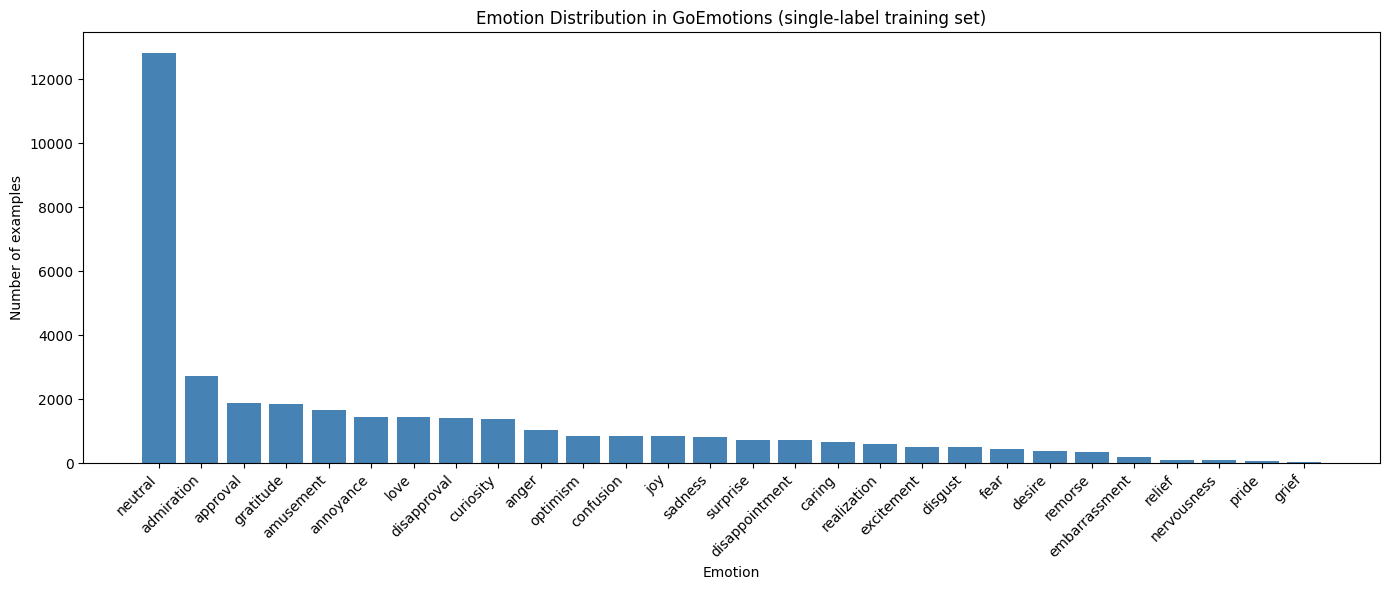


Top 5 most common emotions:
emotion
neutral       12823
admiration     2710
approval       1873
gratitude      1857
amusement      1652
Name: count, dtype: int64

Bottom 5 least common emotions:
emotion
embarrassment    203
relief            88
nervousness       85
pride             51
grief             39
Name: count, dtype: int64


In [12]:
# Now plot the real emotion distribution — 43,000 examples
# Now plot the real emotion distribution — 43,000 examples
emotion_counts = single_df['emotion'].value_counts()

plt.figure(figsize=(14, 6))
plt.bar(emotion_counts.index, emotion_counts.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Emotion Distribution in GoEmotions (single-label training set)')
plt.xlabel('Emotion')
plt.ylabel('Number of examples')
plt.tight_layout()
plt.show()

print("\nTop 5 most common emotions:")
print(emotion_counts.head())
print("\nBottom 5 least common emotions:")
print(emotion_counts.tail()) 

Text length statistics : 
Mean:  12.6 words
Max : 32 words 
Min : 1 words 
Median :  12.0 words


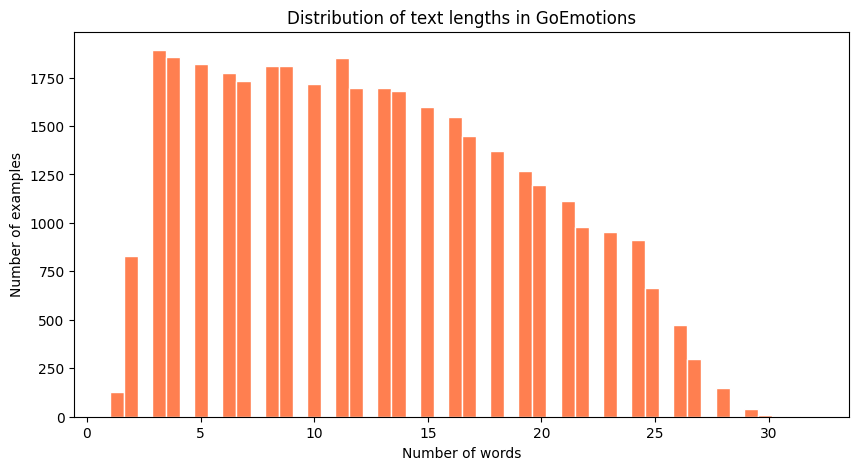

In [8]:
single_df['word_count']= single_df['text'].apply(lambda x: len(x.split()))

print("Text length statistics : ")
print(f"Mean: {single_df['word_count'].mean(): .1f} words")
print(f"Max : {single_df['word_count'].max()} words ")
print(f"Min : {single_df ['word_count'].min()} words ")
print(f"Median : {single_df ['word_count'].median() : .1f} words")

plt.figure(figsize=(10,5))
plt.hist(single_df['word_count'] , bins = 50 , color = 'coral', edgecolor='white')
plt.title('Distribution of text lengths in GoEmotions')
plt.xlabel('Number of words')
plt.ylabel('Number of examples')
plt.show() 